# Analyzing Software Engineering as a Lifecycle Process
- Modeling and concept mapping
- State extraction
- Utility experiment


## 1. Load DuckDB and build weekly counts


Dataset: OpenBB
DuckDB: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\OpenBB.duckdb
OCEL2: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\OpenBB.sqlite
Closed event type id: 65


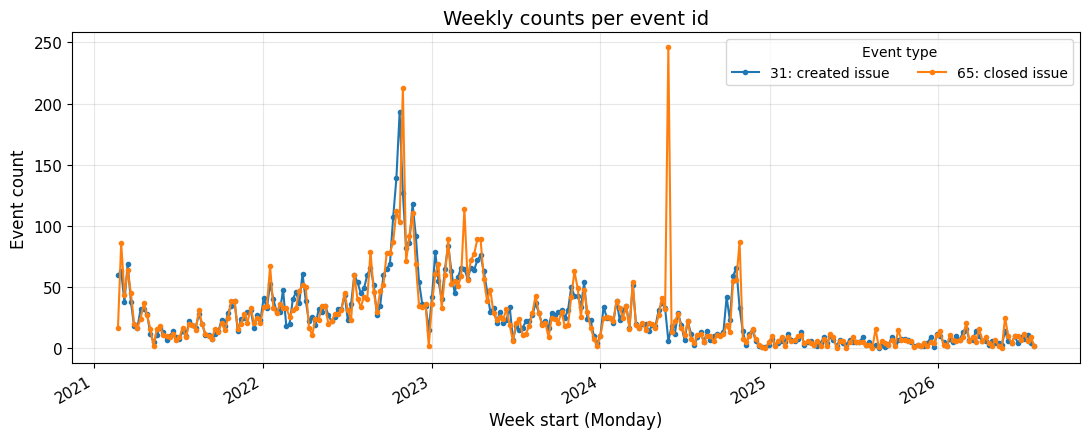

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\OpenBB\weekly_open_closed_summary.csv


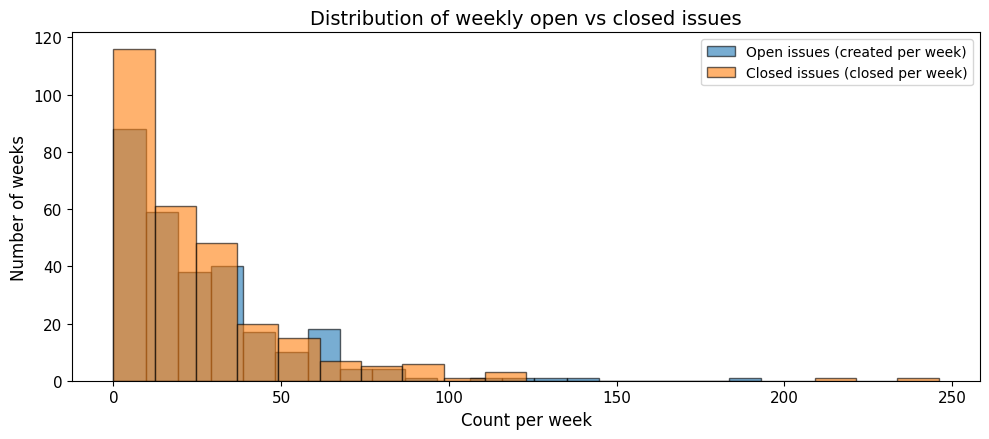

,Open issues (weekly created),Closed issues (weekly closed)
count,284.00,284.00
mean,25.48,25.86
std,25.15,28.66
min,0.00,0.00
25%,7.00,8.00
50%,18.00,18.00
75%,34.25,33.00
max,193.00,246.00


In [1]:
from pathlib import Path

from functions.configs import load_dataset_config
from functions.data_loading import (
    build_weekly_issue_counts,
    load_events_per_obj,
    load_objects_attributes,
)
from functions.plotting_anomaly import (
    plot_weekly_event_counts,
    plot_weekly_open_vs_closed_histogram,
    weekly_open_closed_summary_table,
)

# The only dataset-specific line in this notebook.
cfg = load_dataset_config("OpenBB")

cfg.tables_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_dir.mkdir(parents=True, exist_ok=True)

print("Dataset:", cfg.dataset_name)
print("DuckDB:", cfg.duckdb_path)
print("OCEL2:", cfg.sqlite_path)
print("Closed event type id:", cfg.closed_event_type_id)

eventsPerobj_df = load_events_per_obj(cfg)
objects_attributes = load_objects_attributes(cfg)
weekly = build_weekly_issue_counts(eventsPerobj_df, cfg)
plot_weekly_event_counts(weekly, cfg)
summary_table = weekly_open_closed_summary_table(weekly, cfg)
plot_weekly_open_vs_closed_histogram(weekly, cfg)
summary_table


## 2. Rolling IQR + lexicon state extraction


In [2]:
from functions.anomaly_pipeline import run_anomaly_state_extraction

weekly_closed_anomaly_frame, anomaly_context, anomaly_states, event_closed_title_join = (
    run_anomaly_state_extraction(weekly, eventsPerobj_df, objects_attributes, cfg)
)
anomaly_states.head()


Detected 25 rolling-IQR anomalies for event_type_id=65.
Joined title attribute rows: 7344 of 7344 event rows.
Saved anomaly states to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\OpenBB\anomaly_states.csv


,week_start,value,is_anomaly,anomaly_direction,anomaly_score,lower_bound,upper_bound,title_count,event_count,severity,component,reasoning,extraction_method,confidence,event_descriptions,titles_in_week
0,2021-10-25,39,True,high,0.448718,-4.375,34.625,39,39,P2,api & endpoints,Weekly closures show a near-typical spike (39 ...,rule_based,0.630313,"[closed (#881), closed (#875), closed (#868), ...","[Improve discord help command, fix financedata..."
1,2021-11-01,39,True,high,0.448718,-4.375,34.625,39,39,P2,dependencies,Weekly closures show a near-typical spike (39 ...,rule_based,0.600714,"[closed (#912), closed (#925), closed (#913), ...","[Refactor remaining READMEs, Fix spelling and ..."
2,2022-01-17,67,True,high,2.152174,-3.750,42.250,66,67,P2,testing,Weekly closures show a clearly beyond-typical ...,rule_based,0.662181,"[closed (#1233), closed (#1203), closed (#1202...","[DCF Description, Remove Colorama, Ark Orders ..."
3,2022-07-18,60,True,high,0.825581,8.125,51.125,57,60,P2,documentation,Weekly closures show a slightly beyond-typical...,rule_based,0.662219,"[closed (#2134), closed (#2109), closed (#2104...","[Licensing correct?, The portfolio sheets were..."
4,2022-08-22,79,True,high,1.700000,7.750,57.750,77,79,P2,runtime stability,Weekly closures show a clearly beyond-typical ...,rule_based,0.783405,"[closed (#2414), closed (#2413), closed (#2410...",[Updates Fundamental Analysis Demo Routine - R...


## 3. Export anomaly object / event IDs


In [3]:
from functions.anomaly_ids import export_anomaly_ids

anomaly_object_ids, anomaly_event_ids = export_anomaly_ids(anomaly_context, cfg)
anomaly_object_ids.head()



,week_start,object_id
0,2021-10-25,832758
1,2021-10-25,832826
2,2021-10-25,833332
3,2021-10-25,833412
4,2021-10-25,833471


## 4. Anomaly plots


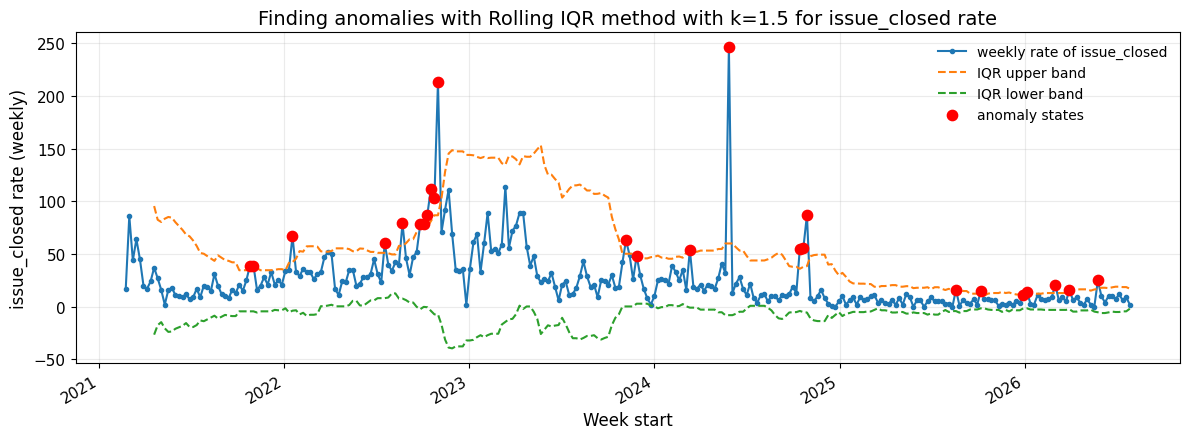

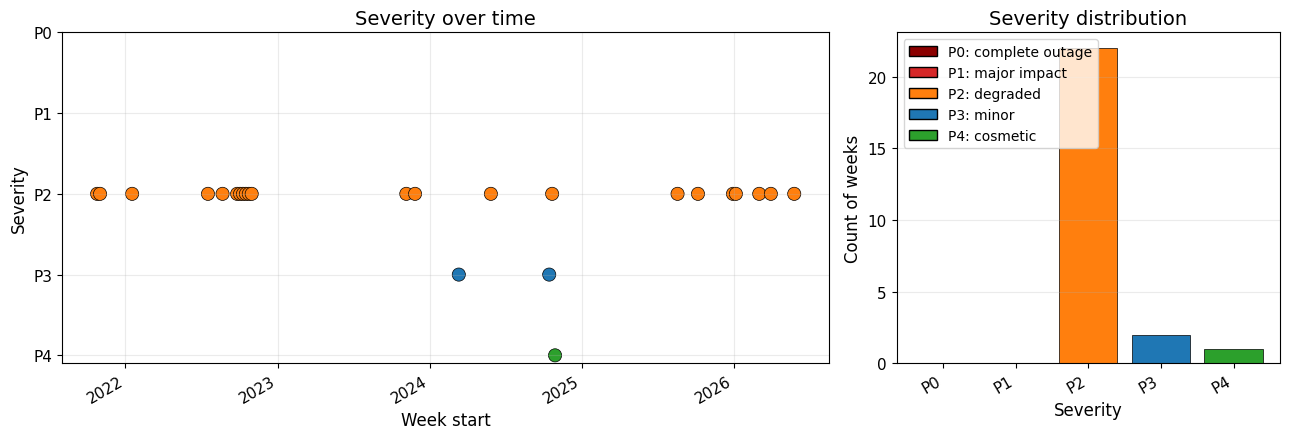

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:391: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 1])


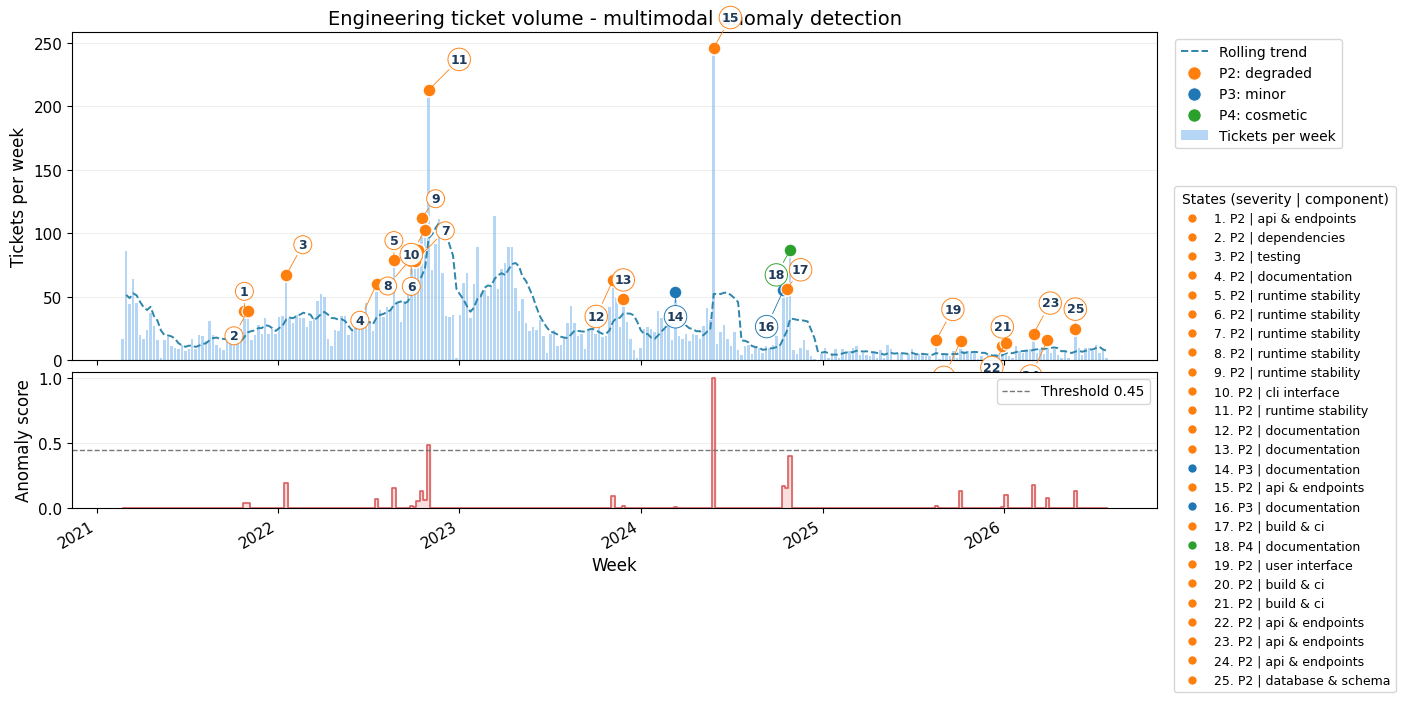

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:503: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 0.985])


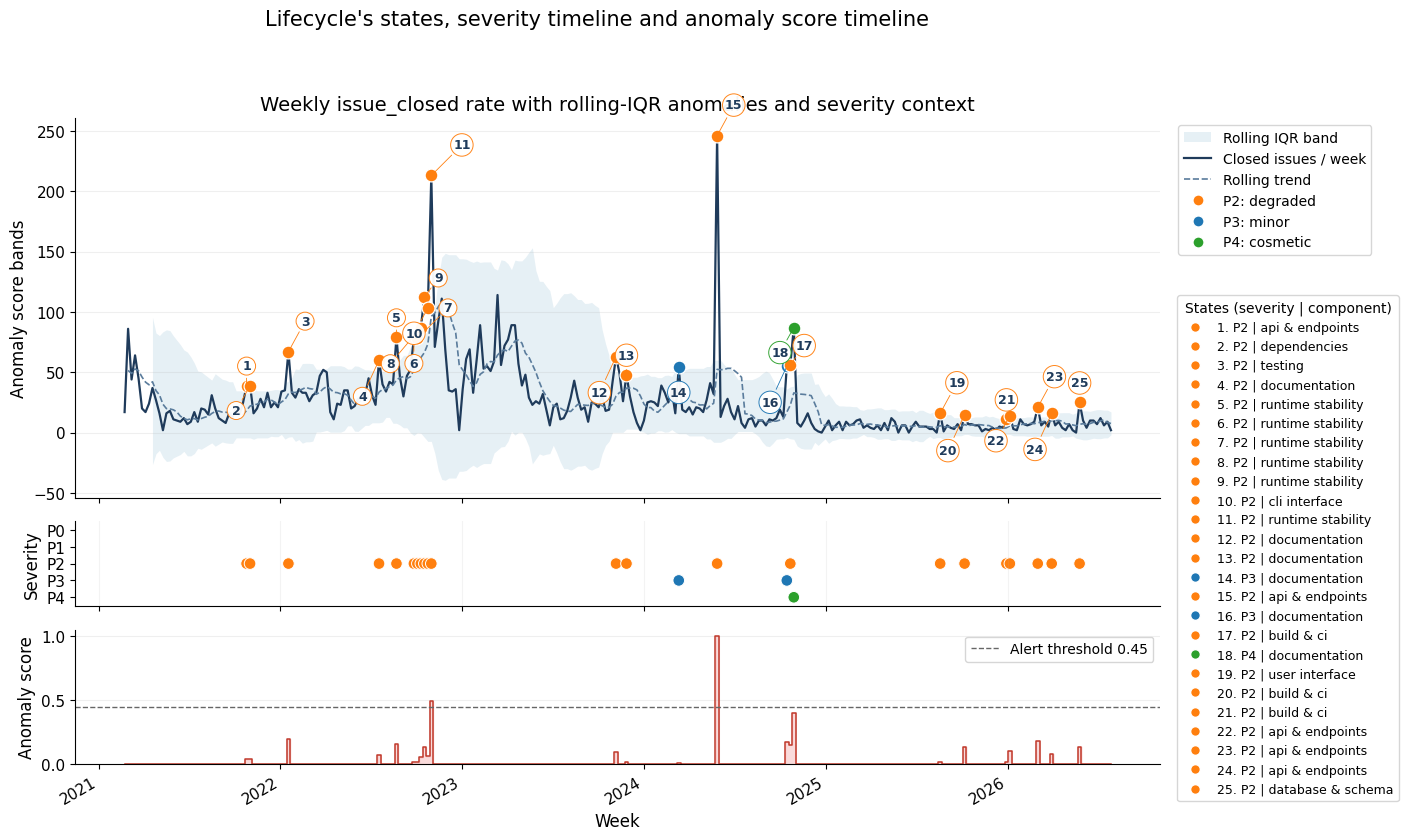

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/OpenBB')

In [4]:
from functions.plotting_anomaly import plot_anomaly_figures

plot_anomaly_figures(weekly_closed_anomaly_frame, anomaly_states, cfg)


## 5. Commit context and type classification


commit_context summary: 25 rows x 17 columns
Saved commit_context to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\OpenBB\commit_context.csv
commit_typeclass_per_week summary: 25 rows x 33 columns

Mean category ratios across all anomaly weeks:
  feature_work  0.010
  bug_fixes     0.016
  tech_debt     0.007
  docs          0.004
  other         0.963

Mean category ratios by anomaly_direction:
  [high] feature_work=0.010  bug_fixes=0.016  tech_debt=0.007  docs=0.004  other=0.963

Saved commit_typeclass_per_week to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\OpenBB\commit_typeclass_per_week.csv


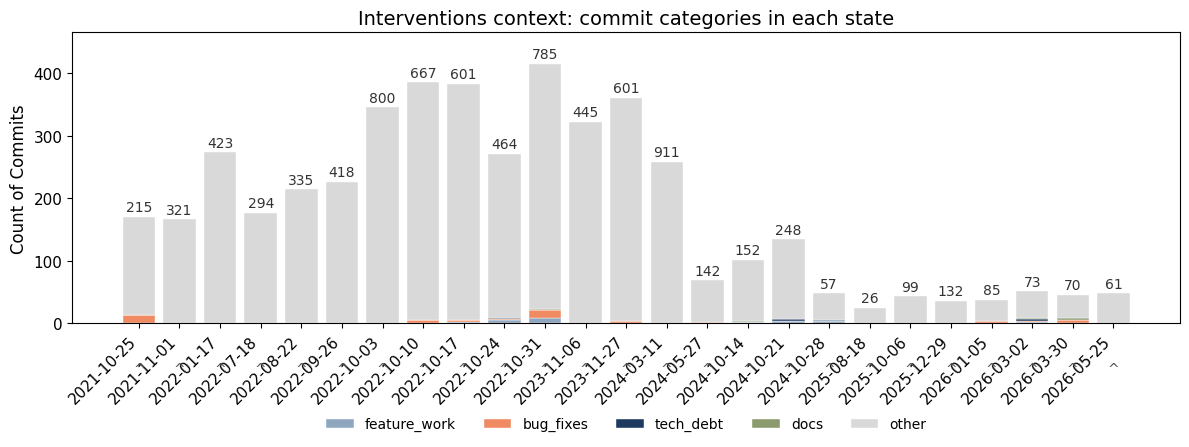

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/OpenBB')

In [5]:
from functions.commits import build_commit_context, build_commit_typeclass
from functions.plotting_anomaly import plot_commit_category_stack

commit_context, event_commit_message_join = build_commit_context(
    weekly_closed_anomaly_frame, eventsPerobj_df, objects_attributes, cfg
)
commit_typeclass_per_week = build_commit_typeclass(commit_context, cfg)
plot_commit_category_stack(commit_context, commit_typeclass_per_week, cfg)


## 6. Flatten OCEL2 issue log


In [6]:
from functions.ocel_flatten import flatten_ocel2_issue_log

flat = flatten_ocel2_issue_log(cfg)


Flattened log: 162662 events, 7236 cases
  case:concept:name      concept:name            time:timestamp
0             10036           created 2026-04-02 09:54:20+00:00
1             10036         commented 2026-04-04 16:57:51+00:00
2             10036            closed 2026-04-04 16:57:52+00:00
3             10036  cross_referenced 2026-04-18 00:01:51+00:00
4             10036  cross_referenced 2026-05-03 15:59:30+00:00
5             10063         committed 2026-04-02 04:33:44+00:00
6             10063           created 2026-04-02 04:45:46+00:00
7             10063           labeled 2026-04-02 04:45:47+00:00
8             10063           labeled 2026-04-02 04:45:47+00:00
9             10063           labeled 2026-04-02 04:45:48+00:00


## 7. Vitalizing subset from anomaly object IDs


In [7]:
from functions.ocel_flatten import build_vitalizing_subset

anomaly_events_df, anomaly_df = build_vitalizing_subset(flat, anomaly_object_ids)


Anomaly events df: 30135 rows, 1664 cases


## 8. Preprocess + random control (MAX_REP / SEED unchanged)


In [8]:
from functions.preprocessing import build_preprocessed_logs

prep = build_preprocessed_logs(flat, anomaly_events_df, cfg)
flat_df_clean = prep["flat_df_clean"]
vitalizing_df_clean = prep["vitalizing_df_clean"]
random_case_control_df_clean = prep["random_case_control_df_clean"]
clean_log_groups_df = prep["clean_log_groups_df"]
all_cases_clean = prep["all_cases_clean"]
num_vital_cases_clean = prep["num_vital_cases_clean"]


=== Repetition cleaning summary (MAX_REP = 5) ===
Vitalizing: 1363 -> 1002 cases | 21001 -> 8619 events
Whole: 5164 -> 3519 cases | 98699 -> 32738 events
Random control (rebuilt): 1002 cases | 9366 events


## 9. Discovery F1 evaluation on clean logs


In [9]:
from functions.discovery import evaluate_clean_logs

consolidated_results_table_clean, clean_log_groups_eventlog, miners = evaluate_clean_logs(
    clean_log_groups_df, cfg
)
consolidated_results_table_clean.head()


c:\Users\mahsa.choopannezhadm\anaconda3\envs\LCP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
replaying log with TBR, completed traces :: 100%|██████████| 731/731 [00:03<00:00, 204.26it/s]

Expected records: 30 | Observed: 30

7) Consolidated results table in clean logs
               log_name         discovery_method  distinct_traces  \
0   random_case_control            alpha_classic              731   
1            vitalizing            alpha_classic              664   
2                 whole            alpha_classic             2227   
3   random_case_control       heuristics_dep_0.6              731   
4            vitalizing       heuristics_dep_0.6              664   
5                 whole       heuristics_dep_0.6             2227   
6   random_case_control       heuristics_dep_0.7              731   
7            vitalizing       heuristics_dep_0.7              664   
8                 whole       heuristics_dep_0.7             2227   
9   random_case_control       heuristics_dep_0.8              731   
10           vitalizing       heuristics_dep_0.8              664   
11                whole       heuristics_dep_0.8             2227   
12  random_case_contro

,log_name,discovery_method,distinct_traces,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,random_case_control,alpha_classic,731,0.718263,0.494727,0.157459,0.238886,156.0,34.0,0.512195,ok,None
1,vitalizing,alpha_classic,664,0.741290,0.455854,0.199281,0.277326,82.0,6.0,1.000000,ok,None
2,whole,alpha_classic,2227,0.818340,0.453528,0.230207,0.305398,154.0,30.0,0.468750,ok,None
3,random_case_control,heuristics_dep_0.6,731,0.528780,0.842013,0.474784,0.607192,920.0,63.0,0.443038,ok,None
4,vitalizing,heuristics_dep_0.6,664,0.564417,0.836090,0.476809,0.607290,679.0,47.0,0.445783,ok,None


## 10. Utility figures


Plotting from 30 successful rows
Miner configs: ['alpha_classic', 'heuristics_dep_0.6', 'heuristics_dep_0.7', 'heuristics_dep_0.8', 'heuristics_dep_0.9', 'inductive_IM', 'inductive_IMf_noise_0.3', 'inductive_IMf_noise_0.4', 'inductive_IMf_noise_0.5', 'inductive_IMf_noise_0.6']
Log groups: ['random_case_control', 'vitalizing', 'whole']
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\OpenBB\clean_log_f_score_grouped_bars.{png,pdf}


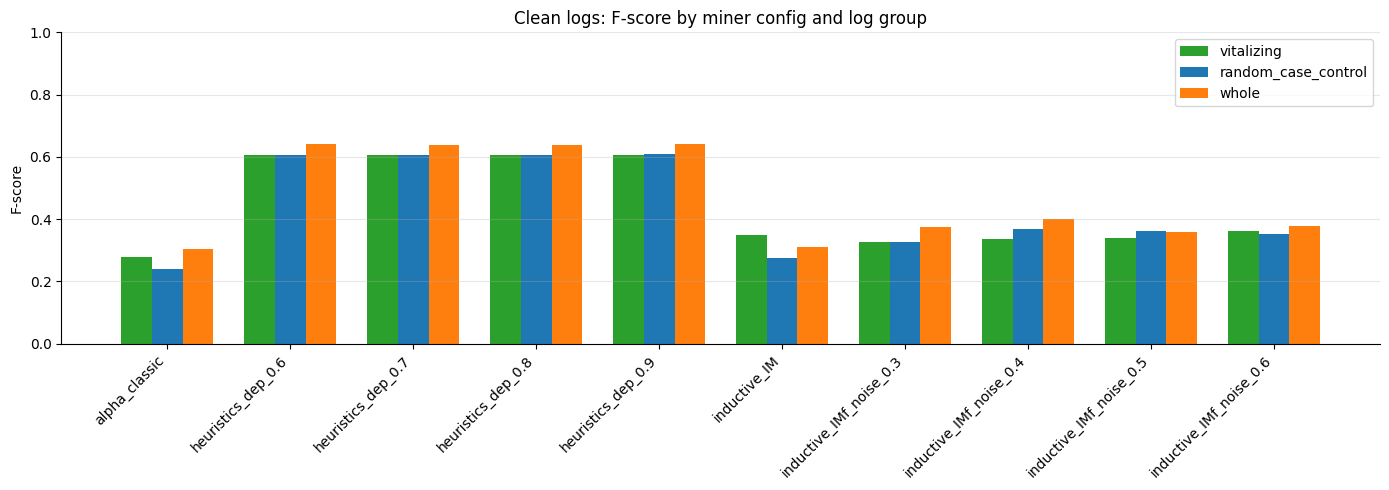

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\OpenBB\clean_log_fitness_precision.{png,pdf}


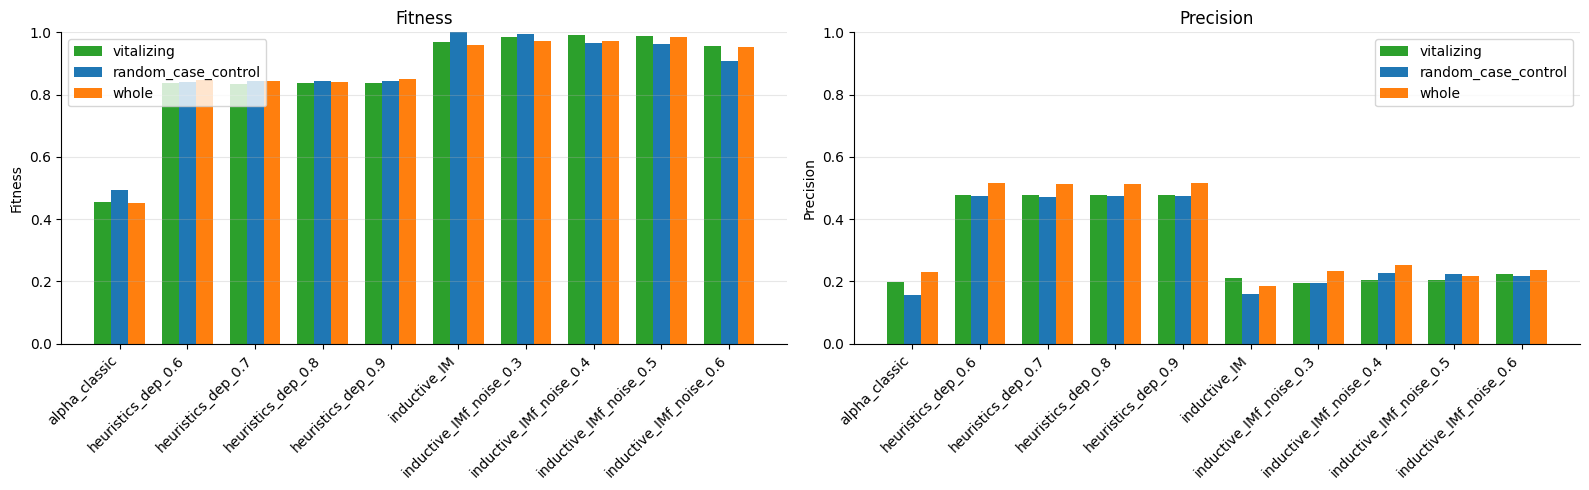

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\OpenBB\clean_log_complexity.{png,pdf}


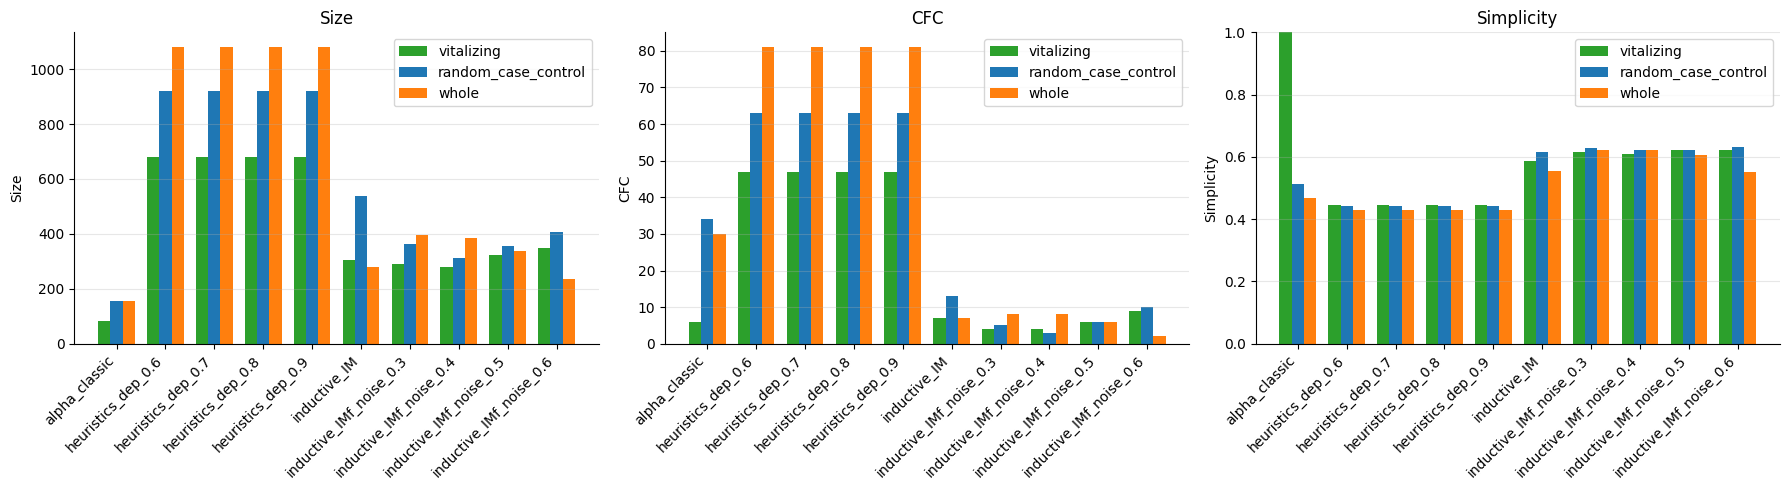

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\OpenBB\clean_log_threshold_sensitivity.{png,pdf}


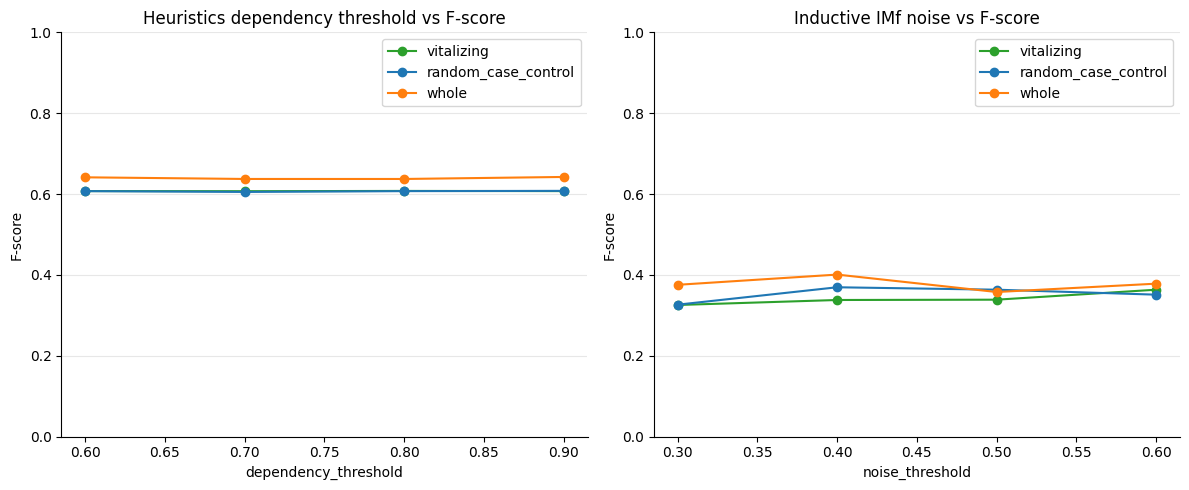

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\OpenBB\clean_log_f_score_slopegraph.{png,pdf}


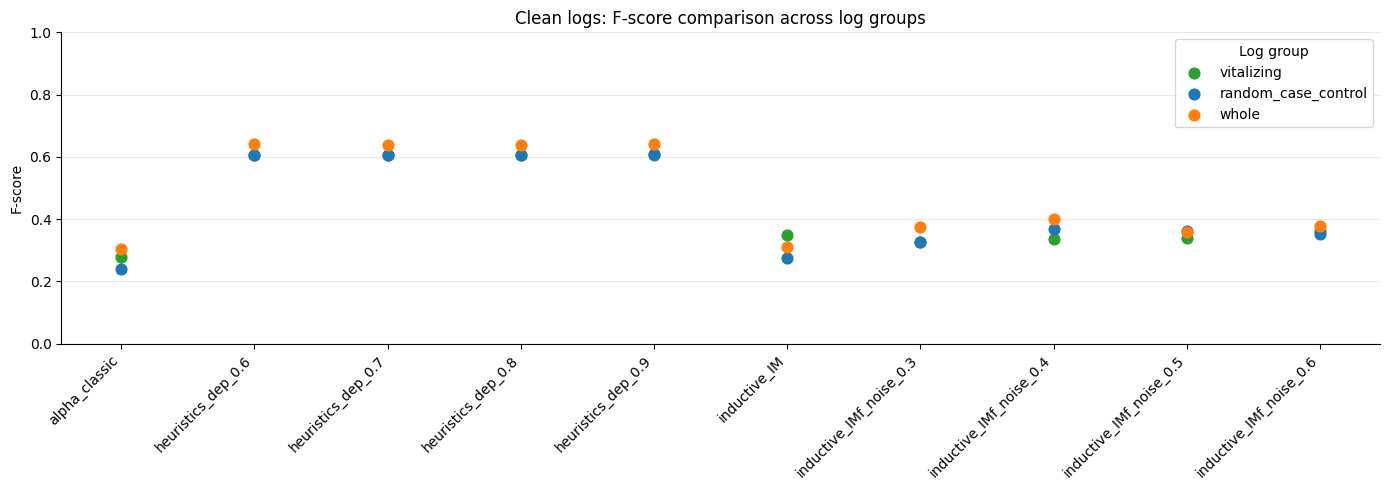

{'wide_f_score_clean': discovery_method     alpha_classic  heuristics_dep_0.6  heuristics_dep_0.7  \
 log_name                                                                     
 random_case_control       0.238886            0.607192            0.605220   
 vitalizing                0.277326            0.607290            0.607034   
 whole                     0.305398            0.641347            0.637279   
 
 discovery_method     heuristics_dep_0.8  heuristics_dep_0.9  inductive_IM  \
 log_name                                                                    
 random_case_control            0.607153            0.607834      0.276932   
 vitalizing                     0.607673            0.607242      0.348035   
 whole                          0.637254            0.642238      0.310494   
 
 discovery_method     inductive_IMf_noise_0.3  inductive_IMf_noise_0.4  \
 log_name                                                                
 random_case_control                 0.32

In [10]:
from functions.plotting_utility import plot_utility_figures

plot_utility_figures(consolidated_results_table_clean, cfg)


## 11. Seed reproducibility


replaying log with TBR, completed traces :: 100%|██████████| 733/733 [00:03<00:00, 184.39it/s]


Reproducibility over 10 seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Discovery metrics summary (mean/std/CV per miner):
          discovery_method  fitness_mean  fitness_std  fitness_cv  \
0            alpha_classic      0.524800     0.055716    0.106167   
1       heuristics_dep_0.6      0.848065     0.004907    0.005786   
2       heuristics_dep_0.7      0.846229     0.007007    0.008281   
3       heuristics_dep_0.8      0.847974     0.004877    0.005751   
4       heuristics_dep_0.9      0.848199     0.006978    0.008227   
5             inductive_IM      0.986781     0.016354    0.016573   
6  inductive_IMf_noise_0.3      0.983646     0.017225    0.017511   
7  inductive_IMf_noise_0.4      0.986783     0.011580    0.011735   
8  inductive_IMf_noise_0.5      0.951152     0.025835    0.027162   
9  inductive_IMf_noise_0.6      0.927879     0.035111    0.037840   

   precision_mean  precision_std  precision_cv  f_score_mean  f_score_std  \
0        0.190818       0.020290      0.106329   

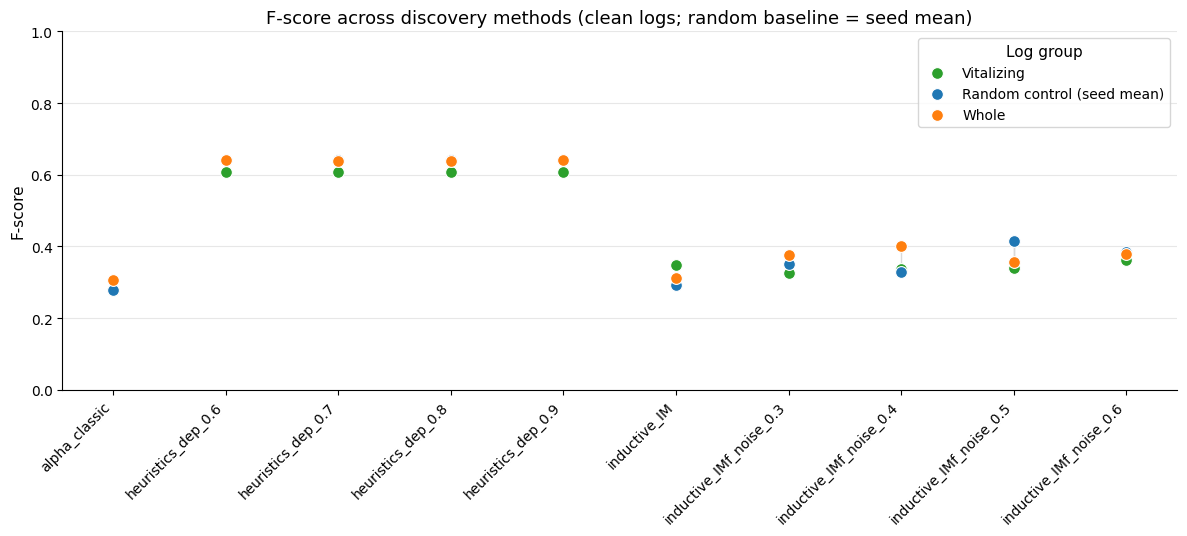

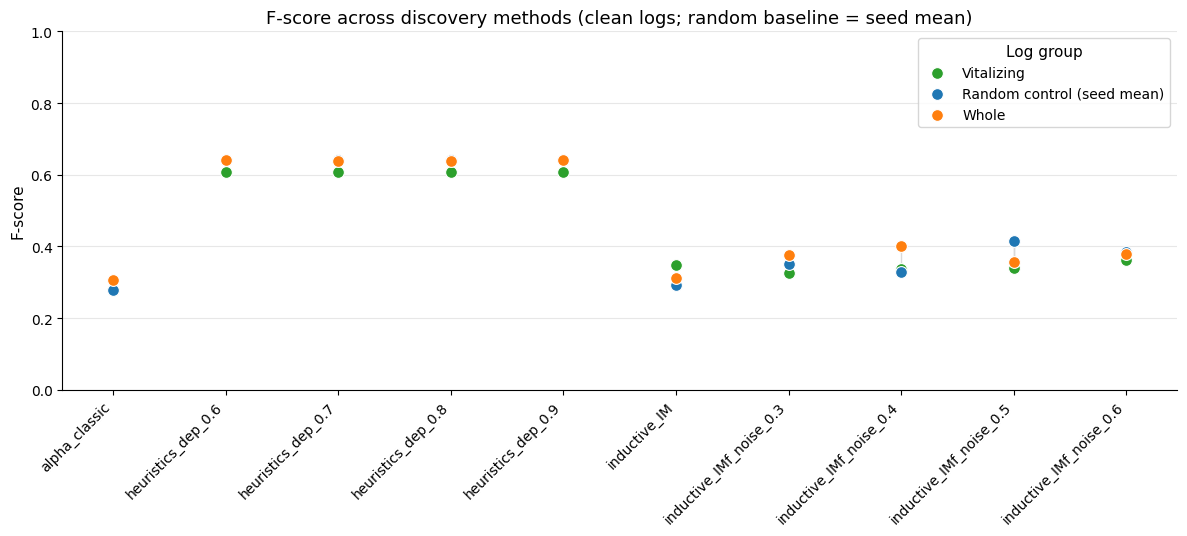

In [11]:
from functions.plotting_utility import plot_repro_slopegraph
from functions.reproducibility import run_seed_reproducibility

repro = run_seed_reproducibility(
    flat_df_clean=flat_df_clean,
    all_cases_clean=all_cases_clean,
    num_vital_cases_clean=num_vital_cases_clean,
    miners=miners,
    consolidated_results_table_clean=consolidated_results_table_clean,
    cfg=cfg,
)
consolidated_results_table_clean_repro = repro["consolidated_results_table_clean_repro"]
plot_repro_slopegraph(consolidated_results_table_clean_repro, cfg)
